# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression for patients with advanced non-small cell lung cancer and high PDL1 receiving first-line pembrolizumab or chemotherapy.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../../aNSCLC/outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(82739, 2)

In [5]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_chemo_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [6]:
pembro_chemo_df.shape

(1803, 164)

In [7]:
df = pd.merge(pembro_chemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1803, 165)

In [9]:
treatment_df = pd.read_csv('../outputs/pembro_chemo_index.csv')

In [10]:
treatment_df.shape

(34491, 3)

In [11]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [12]:
df.shape

(1803, 167)

In [13]:
df['StartDate'] = pd.to_datetime(df['StartDate'])

In [14]:
df['treatment_year'] = df['StartDate'].dt.year

In [15]:
df = df.query('treatment_year <= 2023')

In [16]:
df.shape

(1486, 168)

## Raw Calibration Assessment

In [17]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [18]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.012799999999999999, 0.519]",0.368650,0.274105,149,0.201683,0.345991
1,"(0.519, 0.622]",0.574941,0.452490,149,0.370219,0.531079
2,"(0.622, 0.696]",0.664855,0.536646,148,0.445643,0.607915
3,"(0.696, 0.74]",0.718215,0.634004,149,0.548321,0.703901
4,"(0.74, 0.774]",0.757373,0.692353,148,0.609103,0.760743
5,"(0.774, 0.804]",0.789526,0.774268,149,0.694498,0.831384
6,"(0.804, 0.826]",0.815227,0.821213,148,0.743968,0.871044
7,"(0.826, 0.851]",0.838923,0.853826,149,0.778845,0.897910
8,"(0.851, 0.879]",0.863818,0.889414,148,0.822792,0.928684
9,"(0.879, 0.94]",0.899702,0.952120,149,0.902173,0.976888


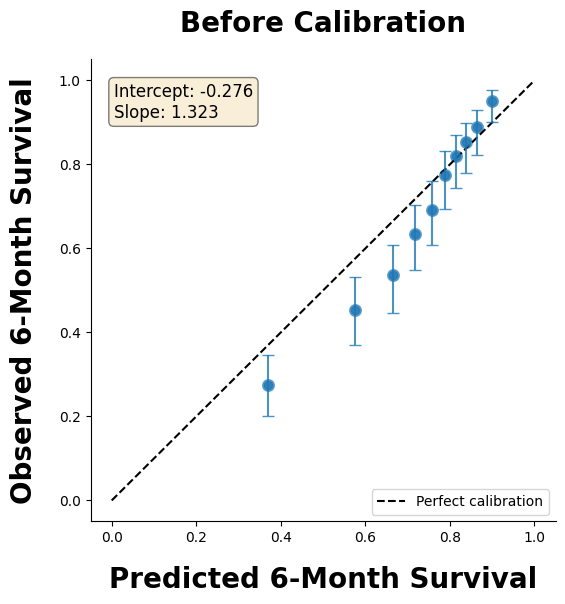

In [19]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [20]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [21]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1764

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1712

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1785

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1819

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1670

=== Summary ===
psurv_180_calibrated computed: 1486

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1750 ± 0.0053


In [22]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [23]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [24]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [25]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.368]",0.256855,0.273376,153,0.202010,0.344252
1,"(0.368, 0.531]",0.477022,0.534478,160,0.453256,0.608982
2,"(0.531, 0.565]",0.546984,0.495986,138,0.402311,0.570488
3,"(0.565, 0.654]",0.639149,0.625683,146,0.538222,0.696374
4,"(0.654, 0.706]",0.683399,0.690241,150,0.607778,0.758425
5,"(0.706, 0.777]",0.754973,0.735595,146,0.650502,0.795943
6,"(0.777, 0.857]",0.824237,0.849389,155,0.777647,0.893956
7,"(0.857, 0.877]",0.870169,0.853761,142,0.776267,0.898554
8,"(0.877, 0.927]",0.903617,0.916164,159,0.857070,0.948586
9,"(0.927, 1.0]",0.964150,0.917941,137,0.856687,0.953711


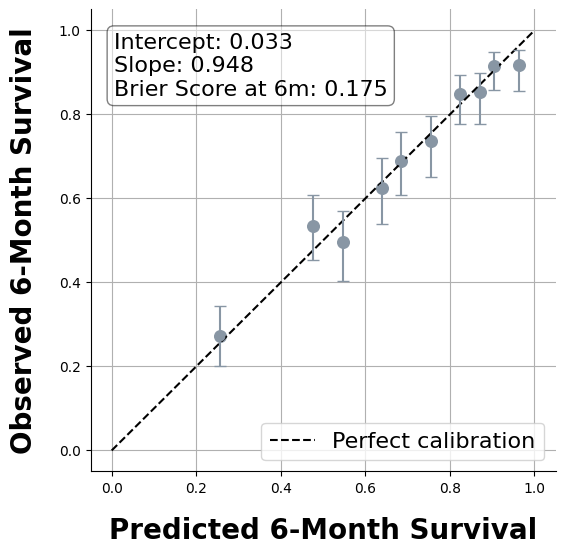

In [26]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()